In [1]:
# 1. Импорт библиотек
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Метрики
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    StackingClassifier
)

# Настройки графиков
sns.set(style="whitegrid")
%matplotlib inline

# Фиксация констант
RANDOM_STATE = 42
TEST_SIZE = 0.25

# Создание папок для артефактов, если их нет
os.makedirs("artifacts/figures", exist_ok=True)

In [2]:
# 2. Загрузка данных

X_synth, y_synth = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_informative=10, 
    n_redundant=5, 
    n_classes=2, 
    flip_y=0.1,  # Добавляем шум (перекрытие классов)
    class_sep=0.8, # Делаем задачу сложнее
    random_state=RANDOM_STATE
)
df = pd.DataFrame(X_synth, columns=[f'feat_{i}' for i in range(20)])
df['target'] = y_synth

# Сохраним для воспроизводимости (эмуляция наличия файла)
df.to_csv("S06-hw-dataset-02.csv", index=False)
print("Dataset generated and saved as S06-hw-dataset-02.csv")
# ---------------------------------------------

# Загрузка
df = pd.read_csv("S06-hw-dataset-02.csv")

# %%
# Первичный анализ
print(f"Shape: {df.shape}")
display(df.head())
display(df.info())
print("\nБаланс классов:")
print(df['target'].value_counts(normalize=True))

Dataset generated and saved as S06-hw-dataset-02.csv
Shape: (2000, 21)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,target
0,-0.221133,-1.193592,-0.369172,-2.560388,-0.806328,0.607880,1.733883,-0.251114,-1.605569,2.004653,...,2.449062,0.798669,0.311935,-0.167249,-0.870726,-0.271044,-1.139875,-0.841817,0.516528,0
1,-1.547224,0.773266,-2.283838,3.276933,1.405041,-0.673822,-0.875419,2.863638,-0.182719,2.857198,...,-1.622869,0.117897,0.076769,0.524543,2.728881,0.226186,3.367872,0.151414,2.211147,0
2,0.589023,0.580422,-0.564948,1.586522,1.545381,0.397404,0.045739,1.037111,0.462142,-4.619606,...,-1.911422,-0.139450,0.366634,0.146858,-3.781484,2.364864,3.105184,-3.154118,-1.069614,0
3,-2.026023,-0.647293,1.055517,0.547164,-3.225189,-0.807595,-0.274984,0.294290,9.391403,-4.464906,...,-5.616602,1.085074,0.472264,2.274378,-0.196486,1.610994,9.488018,-5.750039,3.554828,1
4,-1.064994,1.873415,1.313109,0.668154,-0.069558,-0.964506,1.083218,-4.409095,-0.276223,-4.220245,...,5.149194,-4.452558,2.346129,-3.036125,-5.738073,-2.985661,-3.166884,6.612316,-0.423611,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   feat_0   2000 non-null   float64
 1   feat_1   2000 non-null   float64
 2   feat_2   2000 non-null   float64
 3   feat_3   2000 non-null   float64
 4   feat_4   2000 non-null   float64
 5   feat_5   2000 non-null   float64
 6   feat_6   2000 non-null   float64
 7   feat_7   2000 non-null   float64
 8   feat_8   2000 non-null   float64
 9   feat_9   2000 non-null   float64
 10  feat_10  2000 non-null   float64
 11  feat_11  2000 non-null   float64
 12  feat_12  2000 non-null   float64
 13  feat_13  2000 non-null   float64
 14  feat_14  2000 non-null   float64
 15  feat_15  2000 non-null   float64
 16  feat_16  2000 non-null   float64
 17  feat_17  2000 non-null   float64
 18  feat_18  2000 non-null   float64
 19  feat_19  2000 non-null   float64
 20  target   2000 non-null   int64  
dtypes: float64(20)

None


Баланс классов:
target
0    0.5085
1    0.4915
Name: proportion, dtype: float64


In [3]:
# 3. Split и подготовка

# Используем `stratify`, так как в задачах классификации важно сохранить баланс классов между train и test. Фиксируем `random_state` для воспроизводимости.

# %%
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (1500, 20), Test shape: (500, 20)


In [4]:
# 4. Базовые модели (Baselines)

# Словарь для сбора результатов
results = {}

def evaluate_model(name, model, X_test, y_test, fit_time=None):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # Для DummyClassifier может не быть корректного predict_proba, обработаем
    try:
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = 0.5

    print(f"[{name}] Acc: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}")
    
    return {
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "roc_auc": round(roc, 4)
    }

# --- 1. Dummy Classifier ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
results['Dummy'] = evaluate_model('Dummy', dummy, X_test, y_test)

# --- 2. Logistic Regression (Baseline) ---
# Используем Pipeline для масштабирования
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
results['LogReg'] = evaluate_model('LogReg', pipe_lr, X_test, y_test)

[Dummy] Acc: 0.5080, F1: 0.0000, ROC-AUC: 0.5000
[LogReg] Acc: 0.7400, F1: 0.7325, ROC-AUC: 0.8259


In [5]:
# 5. Модели Week 06 
# Подбор гиперпараметров делаем строго на Train с использованием CV.

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_params_log = {}

# --- 3. Decision Tree (с контролем сложности) ---
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=cv_splitter, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
best_params_log['DecisionTree'] = grid_dt.best_params_
results['DecisionTree'] = evaluate_model('DecisionTree', best_dt, X_test, y_test)
print(f"Best DT Params: {grid_dt.best_params_}")

# --- 4. Random Forest ---
rf = RandomForestClassifier(random_state=RANDOM_STATE)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv_splitter, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_params_log['RandomForest'] = grid_rf.best_params_
results['RandomForest'] = evaluate_model('RandomForest', best_rf, X_test, y_test)
print(f"Best RF Params: {grid_rf.best_params_}")

# --- 5. Gradient Boosting ---
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, param_grid_gb, cv=cv_splitter, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
best_params_log['GradientBoosting'] = grid_gb.best_params_
results['GradientBoosting'] = evaluate_model('GradientBoosting', best_gb, X_test, y_test)
print(f"Best GB Params: {grid_gb.best_params_}")

# --- 6. Stacking (Optional) ---
# Берем лучшие найденные модели как базу
estimators = [
    ('rf', best_rf),
    ('gb', best_gb),
    ('dt', best_dt)
]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=cv_splitter
)
stacking.fit(X_train, y_train)
results['Stacking'] = evaluate_model('Stacking', stacking, X_test, y_test)

[DecisionTree] Acc: 0.7540, F1: 0.7389, ROC-AUC: 0.8152
Best DT Params: {'ccp_alpha': 0.001, 'max_depth': 10, 'min_samples_leaf': 10}
[RandomForest] Acc: 0.8540, F1: 0.8501, ROC-AUC: 0.9165
Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
[GradientBoosting] Acc: 0.8560, F1: 0.8519, ROC-AUC: 0.9215
Best GB Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
[Stacking] Acc: 0.8620, F1: 0.8571, ROC-AUC: 0.9202


In [6]:
# 6. Сравнение и Интерпретация

# Сводная таблица метрик
metrics_df = pd.DataFrame(results).T
display(metrics_df.sort_values('roc_auc', ascending=False))

# Выбираем лучшую модель (по ROC-AUC)
best_model_name = metrics_df['roc_auc'].idxmax()
print(f"Лучшая модель: {best_model_name}")

if best_model_name == 'RandomForest':
    final_model = best_rf
elif best_model_name == 'GradientBoosting':
    final_model = best_gb
elif best_model_name == 'DecisionTree':
    final_model = best_dt
elif best_model_name == 'Stacking':
    final_model = stacking
else:
    final_model = pipe_lr # fallback

,accuracy,f1,roc_auc
GradientBoosting,0.856,0.8519,0.9215
Stacking,0.862,0.8571,0.9202
RandomForest,0.854,0.8501,0.9165
LogReg,0.740,0.7325,0.8259
DecisionTree,0.754,0.7389,0.8152
Dummy,0.508,0.0000,0.5000


Лучшая модель: GradientBoosting


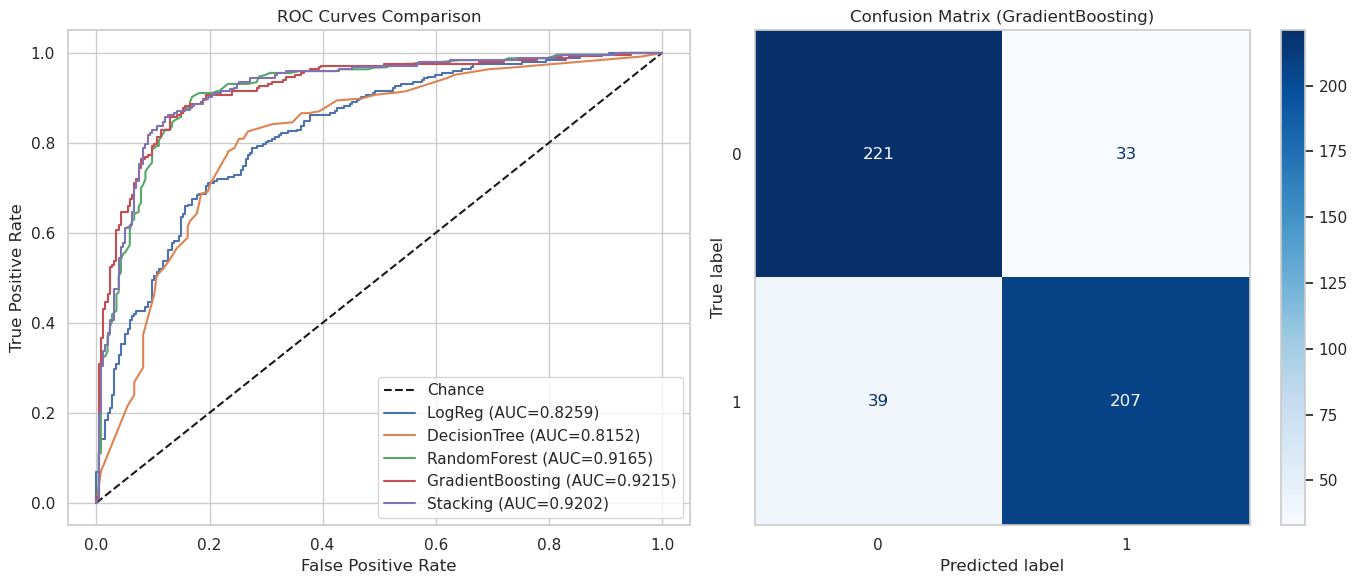

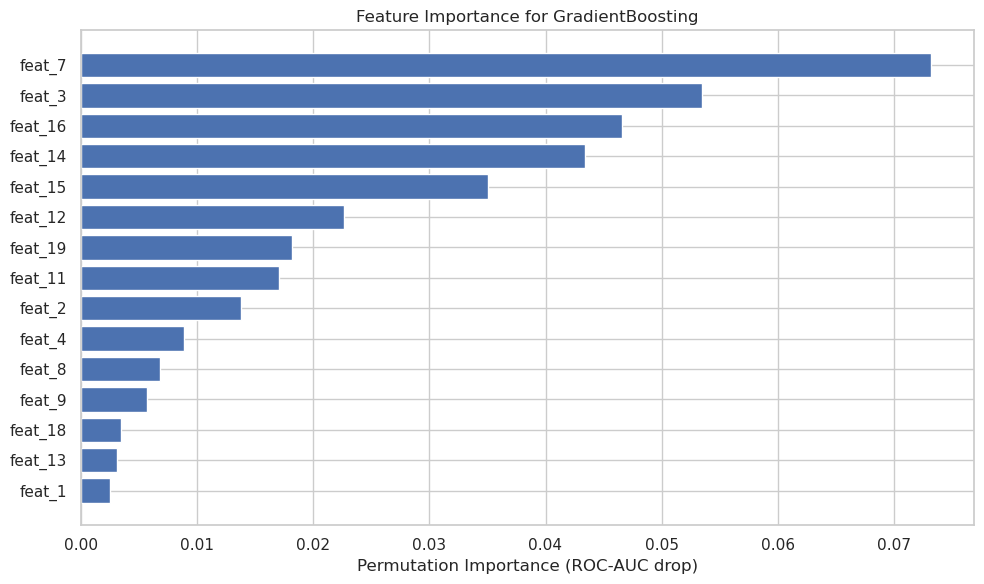

All artifacts saved successfully.


In [7]:
# Графики (ROC Curve & Confusion Matrix)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. ROC Curves
ax[0].plot([0, 1], [0, 1], 'k--', label='Chance')
for name, metrics in results.items():
    if name == 'Dummy': continue
    
    # Получаем модель
    if name == 'LogReg': model = pipe_lr
    elif name == 'DecisionTree': model = best_dt
    elif name == 'RandomForest': model = best_rf
    elif name == 'GradientBoosting': model = best_gb
    elif name == 'Stacking': model = stacking
    
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={metrics['roc_auc']})")

ax[0].set_title('ROC Curves Comparison')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

# 2. Confusion Matrix (для лучшей модели)
y_pred_best = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(ax=ax[1], cmap='Blues', values_format='d')
ax[1].set_title(f'Confusion Matrix ({best_model_name})')
ax[1].grid(False)

plt.tight_layout()
plt.savefig('artifacts/figures/roc_cm_comparison.png')
plt.show()

# %% [markdown]
# ### Permutation Importance

# %%
# Считаем важность признаков для лучшей модели на test
r = permutation_importance(final_model, X_test, y_test,
                           n_repeats=10,
                           random_state=RANDOM_STATE,
                           scoring='roc_auc')

sorted_idx = r.importances_mean.argsort()[::-1][:15] # Top 15

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], r.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (ROC-AUC drop)")
plt.title(f"Feature Importance for {best_model_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('artifacts/figures/feature_importance.png')
plt.show()

# %% [markdown]
# ## 7. Сохранение артефактов

# %%
# 1. Метрики
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(results, f, indent=4)

# 2. Параметры поиска
with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(best_params_log, f, indent=4)

# 3. Лучшая модель
joblib.dump(final_model, 'artifacts/best_model.joblib')

# 4. Метаданные лучшей модели
best_meta = {
    "model_name": best_model_name,
    "metrics": results[best_model_name],
    "params": best_params_log.get(best_model_name, "Stacked/Other")
}
with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_meta, f, indent=4)

print("All artifacts saved successfully.")